# Brain state statistics (k-means, K = 5)



This notebook performs subject-level statistical analyses on brain state features derived from k-means clustering of wSMI connectivity (L1 / Manhattan distance), following the logic of Della Bella et al. (Brain, 2025).



The key steps are:



1. Load subject×condition features:

   - state occupancies \(p_i\) for \(K = 5\)

   - weighted entropy (WE)

   - occupancy entropy \(H_{\text{occ}}\) and its normalized version \(H_{\text{occ\_norm}}\).

2. Define three main experimental condition groups:

   - Resting

   - Familiar voice

   - Medical staff

   - all remaining fine-grained labels are grouped as **Other**.

3. Load state entropies \(H_i\), sort states from low to high entropy, and define:

   - high-entropy states (two highest-entropy states)

   - low-entropy states (two lowest-entropy states)

   - aggregate occupancies \(p_\text{high}\) and \(p_\text{low}\) per subject and condition group.

4. Compute descriptive statistics (mean, SEM, 95% CI) per condition group for:

   - WE

   - \(H_{\text{occ\_norm}}\)

   - \(p_\text{high}\)

   - \(p_\text{low}\).

5. Perform within-subject statistical tests (Friedman + Wilcoxon with effect sizes) across the three core conditions (Resting, Familiar voice, Medical staff).

6. Visualise:

   - state entropy profile \(H_i\) (simple vs complex states)

   - brain state occupancy profiles across states and condition groups

   - subject-level distributions of WE, \(H_{\text{occ\_norm}}\), \(p_\text{high}\), and \(p_\text{low}\).


In [9]:
from pathlib import Path  # For robust path handling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plotting style configuration
sns.set(style="whitegrid", context="talk")  # Use a clean, publication-style theme
plt.rcParams["figure.figsize"] = (10, 6)  # Set a default figure size

# Paths (notebook is assumed to live in notebooks/ at repo root)
FEATURES_CSV = (
    "../data/processed/wsmi/sliding_window16s_stride1s/"
    "sliding_window16s_stride1s_nice_csd/k3_tau8ms/kmeans_assigned_states/"
    "features_subject_condition_k5.csv"
)  # Path to subject×condition features
STATE_ENTROPIES_PATH = (
    "../data/processed/wsmi/sliding_window16s_stride1s/"
    "sliding_window16s_stride1s_nice_csd/k3_tau8ms/kmeans_assigned_states/"
    "state_entropies_k5.npy"
)  # Path to state entropies H_i

# Core condition labels of interest (used for inference)
CORE_CONDITIONS = ["Resting", "Familiar voice", "Medical staff"]


def load_features(features_csv: str) -> pd.DataFrame:
    """Load subject×condition feature table and enforce basic dtypes."""
    df_local = pd.read_csv(features_csv)  # Load subject×condition features

    # Ensure subject and condition columns exist and are strings
    if "condition_name" in df_local.columns:
        cond_col = "condition_name"
    elif "condition" in df_local.columns:
        cond_col = "condition"
    else:
        raise KeyError("Expected a condition column named 'condition_name' or 'condition'.")

    df_local["subject"] = df_local["subject"].astype(str)  # Cast subject IDs to string
    df_local[cond_col] = df_local[cond_col].astype(str)  # Cast condition names to string

    # Create a harmonised column name for downstream code
    df_local = df_local.rename(columns={cond_col: "condition_name"})

    return df_local


def add_condition_group_column(df_in: pd.DataFrame) -> pd.DataFrame:
    """Add a condition_group column mapping fine-grained labels to 4 groups."""
    df = df_in.copy()

    def map_condition_to_group(name: str) -> str:
        """Map raw condition_name to one of the four groups."""
        if name == "Resting":
            return "Resting"
        if name == "Familiar voice":
            return "Familiar voice"
        if name == "Medical staff":
            return "Medical staff"
        return "Other"

    df["condition_group"] = df["condition_name"].apply(map_condition_to_group)
    return df


# Load features CSV and set up condition group
df = load_features(FEATURES_CSV)
df = add_condition_group_column(df)

# Basic sanity printout
print("Shape of features DataFrame:", df.shape)
print("Columns:", df.columns.tolist())
print("Unique subjects:", df["subject"].nunique())
print("Condition groups and counts:")
print(df["condition_group"].value_counts())

# Inspect the first few rows
df.head()

Shape of features DataFrame: (369, 13)
Columns: ['subject', 'condition', 'p_0', 'p_1', 'p_2', 'p_3', 'p_4', 'WE', 'H_occ', 'H_occ_norm', 'n_windows', 'condition_name', 'condition_group']
Unique subjects: 74
Condition groups and counts:
condition_group
Other             147
Familiar voice     74
Medical staff      74
Resting            74
Name: count, dtype: int64


,subject,condition,p_0,p_1,p_2,p_3,p_4,WE,H_occ,H_occ_norm,n_windows,condition_name,condition_group
0,0,19,0.0,0.0,0.000000,0.000000,1.000000,1.905529,0.000000,0.000000,174,Familiar voice,Familiar voice
1,0,32,0.0,0.0,0.045977,0.000000,0.954023,1.910024,0.186495,0.115876,174,Medical staff,Medical staff
2,0,35,0.0,0.0,0.001492,0.000000,0.998508,1.905674,0.011200,0.006959,2681,Other,Other
3,0,37,0.0,0.0,0.013521,0.000000,0.986479,1.906850,0.071616,0.044498,1849,Resting,Resting
4,0,53,0.0,0.0,0.293333,0.213333,0.493333,2.021378,1.037911,0.644890,75,der gives medicin,Other


## State entropies and derived occupancy measures

In this section, state entropies $H_i$ are loaded and used to define:

- **High-entropy states**: the two states with the highest $H_i$.
- **Low-entropy states**: the two states with the lowest $H_i$.

For each subject×condition, two aggregate occupancy measures are then computed:

- $p_\text{high}$: summed occupancy over high-entropy states.
- $p_\text{low}$: summed occupancy over low-entropy states.

These quantities mirror the idea of contrasting more complex vs. more stereotyped brain states.


In [10]:
# Load state entropies H_i (vector of length K = 5)
H_vec = np.load(STATE_ENTROPIES_PATH)  # 1D array of state entropies

# Sanity check on shape
print("H_vec shape:", H_vec.shape)
print("H_vec values:", H_vec)

# Sort states by entropy from low to high
state_indices = np.arange(len(H_vec))  # Indices 0..K-1
sorted_idx_asc = np.argsort(H_vec)  # Indices sorted by H_i from low to high
sorted_idx_desc = sorted_idx_asc[::-1]  # Same indices from high to low

print("States sorted by entropy (low -> high):")
for rank, idx in enumerate(sorted_idx_asc, start=1):
    print(f" Rank {rank}: state {idx} with H_i = {H_vec[idx]:.3f}")

# Define high-entropy and low-entropy state sets (two highest and two lowest)
low_entropy_states = sorted_idx_asc[:2]   # Two lowest-entropy states
high_entropy_states = sorted_idx_desc[:2]  # Two highest-entropy states

print("Low-entropy states:", low_entropy_states)
print("High-entropy states:", high_entropy_states)


def aggregate_occupancy(row: pd.Series, state_indices_subset: np.ndarray) -> float:
    """Return the summed p_i over a subset of state indices for one row."""
    cols = [f"p_{int(i)}" for i in state_indices_subset]  # Column names for requested states
    missing = [c for c in cols if c not in row.index]
    if missing:
        raise KeyError(f"Missing occupancy columns: {missing}")
    return float(row[cols].sum())


# Compute p_high and p_low for each subject×condition_group row
df["p_high"] = df.apply(lambda r: aggregate_occupancy(r, high_entropy_states), axis=1)
df["p_low"] = df.apply(lambda r: aggregate_occupancy(r, low_entropy_states), axis=1)

# Check that p_0..p_4 sum to approximately 1 for each row
p_cols = [c for c in df.columns if c.startswith("p_") and c[2:].isdigit()]
sum_p = df[p_cols].sum(axis=1)
max_deviation = np.abs(sum_p - 1.0).max()
print("Max deviation of sum(p_i) from 1.0:", max_deviation)

# Display a preview of relevant columns
df[["subject", "condition_group"] + p_cols + ["p_high", "p_low"]].head()

H_vec shape: (5,)
H_vec values: [2.36937008 2.12745917 2.00329536 2.31414164 1.90552851]
States sorted by entropy (low -> high):
 Rank 1: state 4 with H_i = 1.906
 Rank 2: state 2 with H_i = 2.003
 Rank 3: state 1 with H_i = 2.127
 Rank 4: state 3 with H_i = 2.314
 Rank 5: state 0 with H_i = 2.369
Low-entropy states: [4 2]
High-entropy states: [0 3]
Max deviation of sum(p_i) from 1.0: 3.3306690738754696e-16


,subject,condition_group,p_0,p_1,p_2,p_3,p_4,p_high,p_low
0,0,Familiar voice,0.0,0.0,0.000000,0.000000,1.000000,0.000000,1.000000
1,0,Medical staff,0.0,0.0,0.045977,0.000000,0.954023,0.000000,1.000000
2,0,Other,0.0,0.0,0.001492,0.000000,0.998508,0.000000,1.000000
3,0,Resting,0.0,0.0,0.013521,0.000000,0.986479,0.000000,1.000000
4,0,Other,0.0,0.0,0.293333,0.213333,0.493333,0.213333,0.786667


## Descriptive statistics by condition

This section summarises, for each condition:

- Weighted entropy (WE)
- Normalised occupancy entropy \(H_{\text{occ\_norm}}\)
- High-entropy occupancy \(p_\text{high}\)
- Low-entropy occupancy \(p_\text{low}\)

For each metric and condition, the following quantities are reported:

- Mean
- Standard deviation
- Standard error of the mean (SEM)
- 95% confidence interval (mean ± 1.96 × SEM)

The section also generates bar plots with 95% confidence intervals and violin/strip plots to visualise the distribution across subjects.



Summary for WE (by condition_group):


,mean,std,sem,ci_low,ci_high,n
condition_group,,,,,,
Resting,1.969472,0.077986,0.009066,1.951703,1.987241,74
Familiar voice,1.976499,0.083407,0.009696,1.957495,1.995503,74
Medical staff,1.979363,0.080767,0.009389,1.960960,1.997765,74
Other,2.027256,0.132626,0.010939,2.005815,2.048696,147


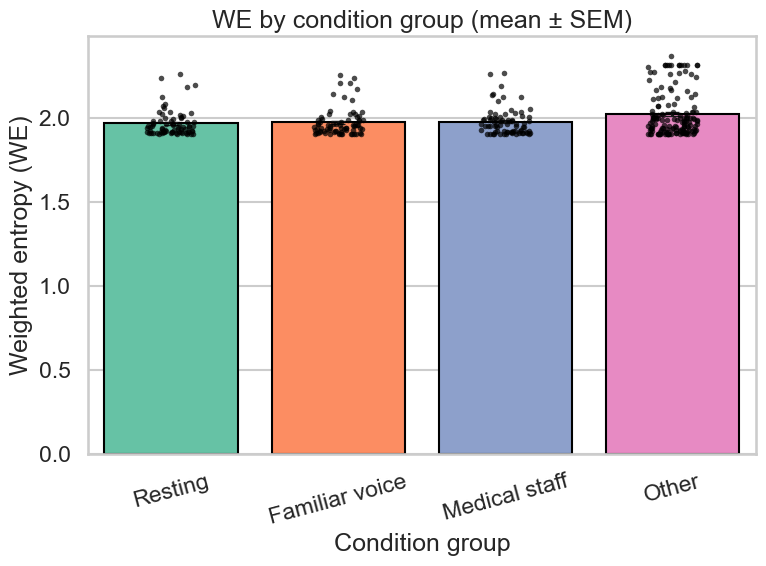


Summary for H_occ_norm (by condition_group):


,mean,std,sem,ci_low,ci_high,n
condition_group,,,,,,
Resting,0.344422,0.180474,0.020980,0.303302,0.385542,74
Familiar voice,0.321499,0.167401,0.019460,0.283357,0.359640,74
Medical staff,0.341148,0.198167,0.023036,0.295996,0.386299,74
Other,0.287203,0.211570,0.017450,0.253001,0.321405,147


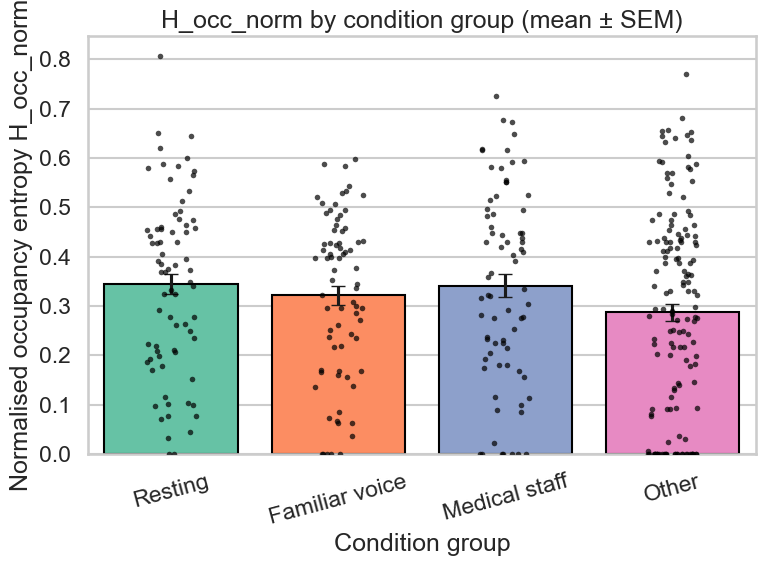


Summary for p_high (by condition_group):


,mean,std,sem,ci_low,ci_high,n
condition_group,,,,,,
Resting,0.074408,0.157691,0.018331,0.038479,0.110337,74
Familiar voice,0.084628,0.177979,0.020690,0.044076,0.125179,74
Medical staff,0.086930,0.167015,0.019415,0.048877,0.124984,74
Other,0.203907,0.333508,0.027507,0.149993,0.257821,147


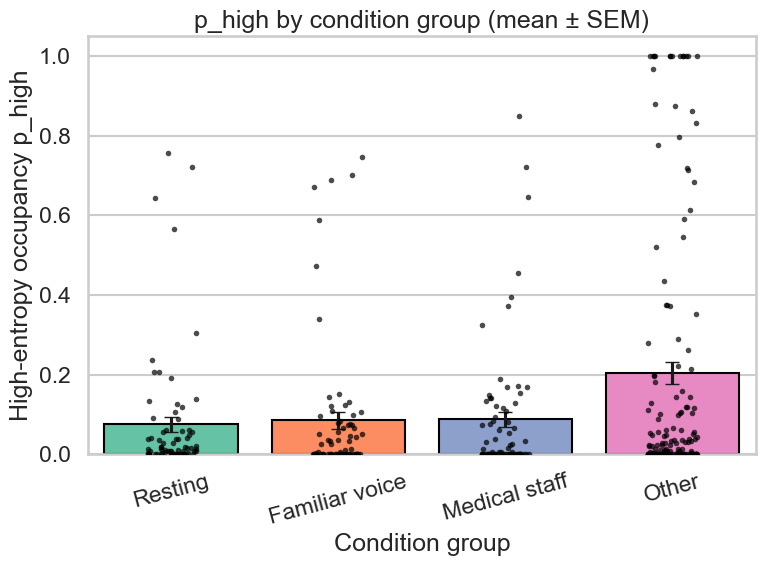


Summary for p_low (by condition_group):


,mean,std,sem,ci_low,ci_high,n
condition_group,,,,,,
Resting,0.910050,0.193830,0.022532,0.865887,0.954213,74
Familiar voice,0.901172,0.209305,0.024331,0.853482,0.948861,74
Medical staff,0.896627,0.201541,0.023429,0.850707,0.942547,74
Other,0.774669,0.354231,0.029216,0.717405,0.831933,147


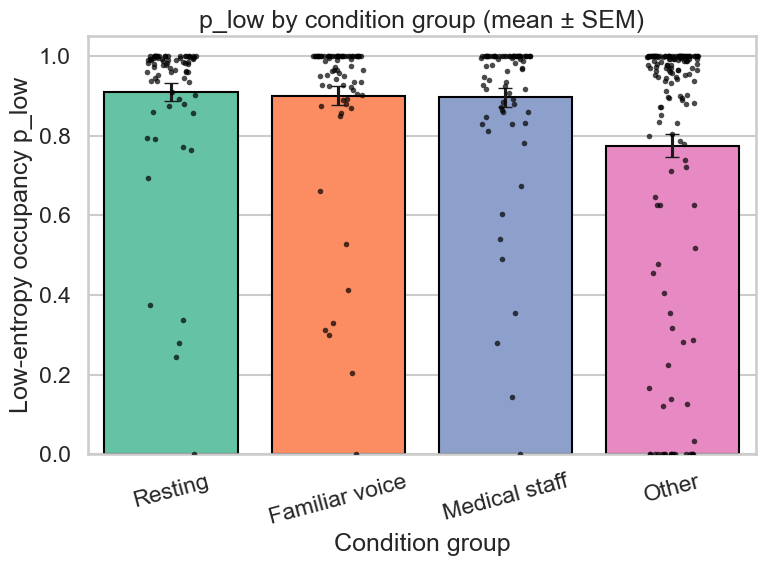

In [11]:
# Helper: summary statistics by condition_group

def summarize_by_group(df_in: pd.DataFrame, metric: str, group_col: str = "condition_group") -> pd.DataFrame:
    """Compute mean, SD, SEM, and 95% CI for a metric grouped by condition_group."""
    grouped = df_in.groupby(group_col)[metric]
    mean = grouped.mean()
    std = grouped.std(ddof=1)
    n = grouped.count()
    sem = std / np.sqrt(n)
    ci_half_width = 1.96 * sem  # Normal-approximation 95% CI

    summary = pd.DataFrame(
        {
            "mean": mean,
            "std": std,
            "sem": sem,
            "ci_low": mean - ci_half_width,
            "ci_high": mean + ci_half_width,
            "n": n,
        }
    )
    return summary


# Order of condition groups for plotting (keep Other last if present)
condition_groups = ["Resting", "Familiar voice", "Medical staff", "Other"]
condition_groups = [c for c in condition_groups if c in df["condition_group"].unique()]

# Colour palette for condition groups
palette = sns.color_palette("Set2", n_colors=len(condition_groups))
condition_to_color = dict(zip(condition_groups, palette))


def plot_metric_by_group(df_in: pd.DataFrame, metric: str, ylabel: str) -> None:
    """Create bar+SEM plot with jittered subject points for a metric by condition_group."""
    summary = summarize_by_group(df_in, metric)
    summary = summary.loc[condition_groups]  # Ensure fixed ordering

    fig, ax = plt.subplots(figsize=(8, 6))

    # Bar plot with SEM error bars
    ax.bar(
        summary.index,
        summary["mean"],
        yerr=summary["sem"],
        capsize=5,
        color=[condition_to_color[c] for c in summary.index],
        edgecolor="black",
    )

    # Overlay subject-level points (one per subject×condition_group)
    sns.stripplot(
        data=df_in,
        x="condition_group",
        y=metric,
        order=condition_groups,
        color="black",
        size=4,
        alpha=0.7,
        ax=ax,
        jitter=0.15,
    )

    ax.set_ylabel(ylabel)
    ax.set_xlabel("Condition group")
    ax.set_title(f"{metric} by condition group (mean ± SEM)")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


# Metrics to summarise and plot
metrics = {
    "WE": "Weighted entropy (WE)",
    "H_occ_norm": "Normalised occupancy entropy H_occ_norm",
    "p_high": "High-entropy occupancy p_high",
    "p_low": "Low-entropy occupancy p_low",
}

summaries = {}
for metric, ylabel in metrics.items():
    print(f"\nSummary for {metric} (by condition_group):")
    summary_metric = summarize_by_group(df, metric)
    summary_metric = summary_metric.loc[condition_groups]
    display(summary_metric)
    summaries[metric] = summary_metric
    plot_metric_by_group(df, metric, ylabel)


## Within-subject statistical tests across conditions

The design is within-subject: each subject contributes data for all three conditions (Familiar voice, Medical staff, Resting).

To follow the spirit of Della Bella et al., condition effects on subject-level metrics are assessed as follows:

1. For each metric, the data are reshaped into a wide format with one row per subject and one column per condition.
2. A non-parametric **Friedman test** is used to test for an overall condition effect.
3. If the Friedman test is significant, **pairwise Wilcoxon signed-rank tests** are conducted between conditions:
   - Familiar vs Medical
   - Familiar vs Resting
   - Medical vs Resting
4. For each pairwise comparison, the following quantities are reported:
   - test statistic and p-value
   - paired Cohen’s \(d\)
   - mean difference and its 95% confidence interval.


In [12]:
# Helper: reshape to wide subject×condition table using condition_group

def to_wide(
    df_in: pd.DataFrame,
    metric: str,
    subject_col: str = "subject",
    condition_col: str = "condition_group",
    condition_order: list | None = None,
) -> pd.DataFrame:
    """Convert long-form DataFrame to wide format (subjects × conditions) for a metric."""
    if condition_order is None:
        condition_order = sorted(df_in[condition_col].unique())

    wide = df_in.pivot_table(
        index=subject_col,
        columns=condition_col,
        values=metric,
        aggfunc="mean",
    )

    # Restrict to requested condition_order and drop incomplete subjects
    wide = wide.loc[:, [c for c in condition_order if c in wide.columns]]
    wide = wide.dropna(axis=0, how="any")
    return wide


def wilcoxon_with_effect_size(x: np.ndarray, y: np.ndarray) -> dict:
    """Run Wilcoxon signed-rank test and compute effect size r = Z / sqrt(N)."""
    stat, p_val = stats.wilcoxon(x, y)

    # Approximate Z from the Wilcoxon statistic using normal approximation
    n = len(x)
    # Mean and variance under H0 for Wilcoxon signed-rank statistic
    mean_w = n * (n + 1) / 4
    var_w = n * (n + 1) * (2 * n + 1) / 24
    z = (stat - mean_w) / np.sqrt(var_w)
    r = z / np.sqrt(n)

    return {"stat": stat, "p": p_val, "z": z, "r": r, "n": n}


def holm_correction(p_values: list[float]) -> list[float]:
    """Apply Holm correction to a list of p-values and return adjusted values."""
    m = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.empty(m, dtype=float)
    for rank, idx in enumerate(order, start=1):
        adjusted[idx] = (m - rank + 1) * p_values[idx]
    # Ensure monotonicity and cap at 1
    for i in range(1, m):
        adjusted[order[i]] = max(adjusted[order[i]], adjusted[order[i - 1]])
    adjusted = np.minimum(adjusted, 1.0)
    return adjusted.tolist()


def run_within_subject_tests(
    df_in: pd.DataFrame,
    metric: str,
    condition_order: list[str],
) -> tuple[float, float, pd.DataFrame]:
    """Run Friedman test and Wilcoxon post-hoc comparisons for one metric."""
    print(f"\n=== Within-subject tests for {metric} ===")

    # Restrict to the three core conditions only
    core_order = [c for c in condition_order if c in CORE_CONDITIONS]
    df_core = df_in[df_in["condition_group"].isin(core_order)].copy()

    wide = to_wide(df_core, metric, condition_order=core_order)
    print("Wide table shape (subjects × conditions):", wide.shape)

    data_arrays = [wide[c].values for c in core_order]

    # Friedman test across the three conditions
    friedman_stat, friedman_p = stats.friedmanchisquare(*data_arrays)
    print(f"Friedman test: chi2 = {friedman_stat:.3f}, p = {friedman_p:.8f}")

    # Pairwise Wilcoxon comparisons (only meaningful with ≥2 subjects)
    pairs = [
        ("Resting", "Familiar voice"),
        ("Resting", "Medical staff"),
        ("Familiar voice", "Medical staff"),
    ]
    pairs = [(a, b) for a, b in pairs if a in wide.columns and b in wide.columns]

    results = []
    raw_p_values = []

    for a, b in pairs:
        x = wide[a].values
        y = wide[b].values
        diff = x - y

        try:
            res = wilcoxon_with_effect_size(x, y)
        except ValueError as exc:
            print(f"Wilcoxon failed for {a} vs {b}: {exc}")
            continue

        # Descriptive paired statistics (median and IQR of differences)
        diff_median = np.median(diff)
        q1 = np.percentile(diff, 25)
        q3 = np.percentile(diff, 75)

        results.append(
            {
                "comparison": f"{a} - {b}",
                "statistic": res["stat"],
                "p_raw": res["p"],
                "z": res["z"],
                "r_effect_size": res["r"],
                "n": res["n"],
                "diff_median": diff_median,
                "diff_q1": q1,
                "diff_q3": q3,
            }
        )
        raw_p_values.append(res["p"])

    # Apply Holm correction across the pairwise tests
    if raw_p_values:
        p_holm = holm_correction(raw_p_values)
        for row, p_corr in zip(results, p_holm, strict=False):
            row["p_holm"] = p_corr

    results_df = pd.DataFrame(results)
    display(results_df)

    return friedman_stat, friedman_p, results_df


friedman_results = {}
for metric in ["WE", "H_occ_norm", "p_high", "p_low"]:
    friedman_results[metric] = run_within_subject_tests(df, metric, condition_groups)



=== Within-subject tests for WE ===
Wide table shape (subjects × conditions): (74, 3)
Friedman test: chi2 = 0.422, p = 0.80971523


,comparison,statistic,p_raw,z,r_effect_size,n,diff_median,diff_q1,diff_q3,p_holm
0,Resting - Familiar voice,1246.0,0.565633,-0.762294,-0.088615,74,-0.000102,-0.015361,0.010672,0.584615
1,Resting - Medical staff,1083.0,0.194872,-1.640413,-0.190694,74,-0.000224,-0.027401,0.010135,0.584615
2,Familiar voice - Medical staff,1069.0,0.231098,-1.715835,-0.199462,74,-0.001383,-0.020205,0.007195,0.584615



=== Within-subject tests for H_occ_norm ===
Wide table shape (subjects × conditions): (74, 3)
Friedman test: chi2 = 3.038, p = 0.21892389


,comparison,statistic,p_raw,z,r_effect_size,n,diff_median,diff_q1,diff_q3,p_holm
0,Resting - Familiar voice,1066.0,0.117805,-1.731996,-0.201340,74,0.033327,-0.061223,0.101330,0.353414
1,Resting - Medical staff,1193.0,0.497128,-1.047817,-0.121806,74,0.003098,-0.082335,0.104002,0.773852
2,Familiar voice - Medical staff,1127.0,0.386926,-1.403375,-0.163139,74,0.000000,-0.122925,0.069576,0.773852



=== Within-subject tests for p_high ===
Wide table shape (subjects × conditions): (74, 3)
Friedman test: chi2 = 5.333, p = 0.06948345


,comparison,statistic,p_raw,z,r_effect_size,n,diff_median,diff_q1,diff_q3,p_holm
0,Resting - Familiar voice,889.0,0.684870,-2.685537,-0.312187,74,0.000229,-0.017375,0.013828,1.000000
1,Resting - Medical staff,972.0,0.805326,-2.238397,-0.260208,74,0.000528,-0.014604,0.024203,1.000000
2,Familiar voice - Medical staff,462.0,0.280418,-4.985887,-0.579598,74,0.000000,-0.029081,0.004546,0.841255



=== Within-subject tests for p_low ===
Wide table shape (subjects × conditions): (74, 3)
Friedman test: chi2 = 4.531, p = 0.10379011


,comparison,statistic,p_raw,z,r_effect_size,n,diff_median,diff_q1,diff_q3,p_holm
0,Resting - Familiar voice,969.0,0.498804,-2.254558,-0.262087,74,-0.000229,-0.015605,0.017375,0.997608
1,Resting - Medical staff,1057.0,0.756694,-1.780481,-0.206977,74,-0.000528,-0.018031,0.014604,0.997608
2,Familiar voice - Medical staff,764.5,0.193330,-3.356248,-0.390156,74,0.000000,-0.004054,0.031586,0.579990


## Brain state occupancy profiles across states and conditions

Beyond aggregate measures such as WE and \(H_{\text{occ\_norm}}\), it is informative to visualise how individual brain states contribute to each condition.

In this section:

- Mean occupancy \(p_i\) is computed for each state and condition.
- Standard error and 95% confidence intervals are also derived.
- Two plots are generated:
  1. A line plot of mean occupancy per state, with separate lines for each condition and shaded 95% confidence intervals.
  2. A heatmap of mean occupancy (state × condition), summarising the same information in matrix form.

These visualisations mirror the way Della Bella et al. present brain state occurrence patterns across groups.


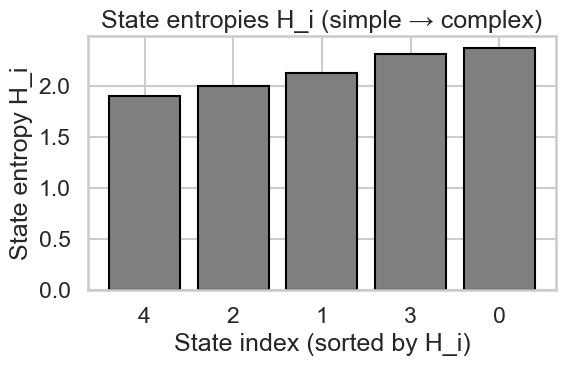

,condition_group,state,mean,sem,n
0,Familiar voice,0,0.009555,0.009467,74
1,Familiar voice,1,0.014201,0.013522,74
2,Familiar voice,2,0.334581,0.032837,74
3,Familiar voice,3,0.075073,0.018887,74
4,Familiar voice,4,0.566591,0.040510,74


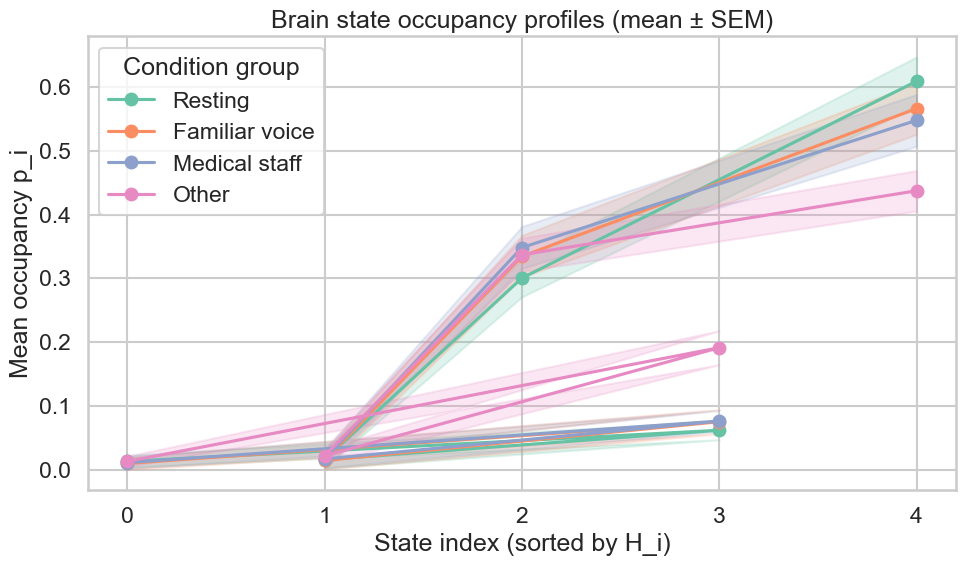

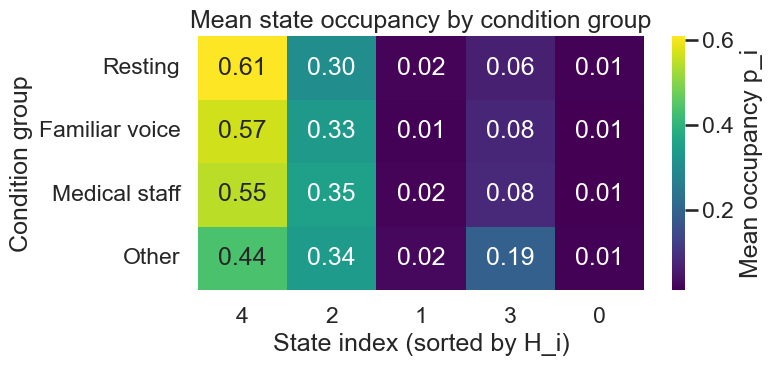

In [13]:
# Plot state entropies H_vec (low to high)

entropy_order = np.argsort(H_vec)  # States from lowest to highest entropy
H_sorted = H_vec[entropy_order]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(H_sorted)), H_sorted, color="tab:gray", edgecolor="black")
ax.set_xticks(range(len(H_sorted)))
ax.set_xticklabels(entropy_order)
ax.set_xlabel("State index (sorted by H_i)")
ax.set_ylabel("State entropy H_i")
ax.set_title("State entropies H_i (simple → complex)")
plt.tight_layout()
plt.show()

# Compute mean occupancy per state and condition_group
state_cols = [c for c in df.columns if c.startswith("p_") and c[2:].isdigit()]

rows = []
for _, row in df.iterrows():
    subj = row["subject"]
    cond = row["condition_group"]
    for state_col in state_cols:
        state_idx = int(state_col.split("_")[1])
        rows.append(
            {
                "subject": subj,
                "condition_group": cond,
                "state": state_idx,
                "p": row[state_col],
            }
        )

df_states_long = pd.DataFrame(rows)

# Reorder states according to increasing entropy for plotting
state_order = list(entropy_order)

# Summary stats per state × condition_group
grouped = df_states_long.groupby(["condition_group", "state"])
mean_p = grouped["p"].mean()
std_p = grouped["p"].std(ddof=1)
n_p = grouped["p"].count()
sem_p = std_p / np.sqrt(n_p)

state_summary = (
    pd.DataFrame(
        {
            "mean": mean_p,
            "sem": sem_p,
            "n": n_p,
        }
    )
    .reset_index()
)

display(state_summary.head())

# Line plot of mean occupancy with SEM bands
fig, ax = plt.subplots(figsize=(10, 6))

for cond in condition_groups:
    subset = state_summary[state_summary["condition_group"] == cond].copy()
    subset = subset.set_index("state").loc[state_order].reset_index()
    x = subset["state"].values
    y = subset["mean"].values
    sem_vals = subset["sem"].values

    ax.plot(
        x,
        y,
        marker="o",
        label=cond,
        color=condition_to_color.get(cond, "tab:gray"),
    )
    ax.fill_between(
        x,
        y - sem_vals,
        y + sem_vals,
        alpha=0.2,
        color=condition_to_color.get(cond, "tab:gray"),
    )

ax.set_xlabel("State index (sorted by H_i)")
ax.set_ylabel("Mean occupancy p_i")
ax.set_title("Brain state occupancy profiles (mean ± SEM)")
ax.set_xticks(state_order)
ax.legend(title="Condition group")
plt.tight_layout()
plt.show()

# Heatmap of mean occupancy (state × condition_group) in entropy order
heatmap_data = state_summary.pivot(
    index="condition_group", columns="state", values="mean"
)
heatmap_data = heatmap_data.loc[condition_groups, state_order]

plt.figure(figsize=(8, 4))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Mean occupancy p_i"},
)
plt.title("Mean state occupancy by condition group")
plt.xlabel("State index (sorted by H_i)")
plt.ylabel("Condition group")
plt.tight_layout()
plt.show()

## Notes for the manuscript

The notebook now provides:

- Subject-level descriptive statistics (mean, SEM, 95% CI) for:
  - WE
  - \(H_{\text{occ\_norm}}\)
  - high-entropy occupancy \(p_\text{high}\)
  - low-entropy occupancy \(p_\text{low}\)
- Within-subject non-parametric tests (Friedman + Wilcoxon) comparing conditions for each metric.
- Brain state occupancy profiles across states and conditions, with:
  - line plots (mean ± 95% CI)
  - heatmaps of mean occupancy.

These outputs can be used to construct result tables and figures that closely follow the structure of Della Bella et al., while being adapted to the present within-subject design and k-means (L1 / Manhattan)–based brain states.
